In [683]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,IterativeImputer,KNNImputer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder,TargetEncoder,MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from sklearn.compose import ColumnTransformer   
from sklearn.pipeline import Pipeline

import pickle
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [684]:
df=pd.read_csv("cars_data.csv")

In [685]:
df

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1,6451.0
...,...,...,...,...,...,...,...,...
995,Nissan,2018.0,21052.0,1.8,Electric,Automatic,4,13831.0
996,Toyota,2017.0,105689.0,2.0,Hybrid,Manual,2,6296.0
997,Mercedes,2021.0,183148.0,3.8,Hybrid,Automatic,2,19708.0
998,Mazda,2018.0,189492.0,1.9,Diesel,Automatic,5,3283.0


In [686]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  950 non-null    object 
 7   Price            987 non-null    float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [687]:
df.describe(include="all")

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
count,979,974.000000,979.000000,964.000000,982,962,950,987.000000
unique,8,NaN,NaN,NaN,4,2,6,NaN
top,Mercedes,NaN,NaN,NaN,Petrol,Automatic,5,NaN
freq,144,NaN,NaN,NaN,261,489,197,NaN
mean,NaN,2016.320329,104185.955056,2.490560,NaN,NaN,NaN,8473.716312
std,NaN,4.050561,56333.931315,0.866082,NaN,NaN,NaN,6301.920977
min,NaN,2010.000000,5207.000000,1.000000,NaN,NaN,NaN,3000.000000
25%,NaN,2013.000000,54002.500000,1.800000,NaN,NaN,NaN,4068.000000
50%,NaN,2016.000000,104853.000000,2.500000,NaN,NaN,NaN,6426.000000
75%,NaN,2020.000000,155030.000000,3.200000,NaN,NaN,NaN,10917.000000


In [688]:
# ================= Feature Engineering =================

df["Car_Age"] = 2026 - df["Year"]

In [689]:
df=df.replace(" ",np.nan)

In [690]:
df=df.dropna(subset=["Price","Previous_Owners"],axis=0)
df.reset_index(drop=True,inplace=True)

In [691]:
df.duplicated().sum()

np.int64(0)

In [692]:
df.shape

(944, 9)

In [693]:
df.isna().sum().sort_values(ascending=False)

Engine_Size        28
Brand              21
Transmission       21
Car_Age            19
Year               19
Mileage            14
Fuel_Type          11
Previous_Owners     0
Price               0
dtype: int64

<Axes: >

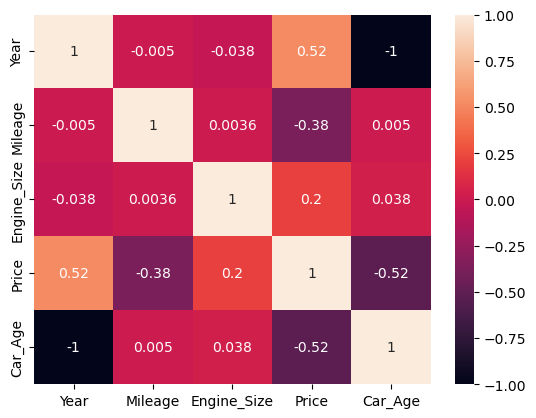

In [694]:
df_corr=df.corr(numeric_only=True)
sns.heatmap(df_corr,annot=True)

In [695]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            923 non-null    object 
 1   Year             925 non-null    float64
 2   Mileage          930 non-null    float64
 3   Engine_Size      916 non-null    float64
 4   Fuel_Type        933 non-null    object 
 5   Transmission     923 non-null    object 
 6   Previous_Owners  944 non-null    object 
 7   Price            944 non-null    float64
 8   Car_Age          925 non-null    float64
dtypes: float64(5), object(4)
memory usage: 66.5+ KB


In [696]:
df["Previous_Owners"]=df["Previous_Owners"].astype(int)

In [697]:
x=df.drop(["Price"],axis=1)
y=df["Price"]

In [698]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

=====Year====
0.0243916502555361


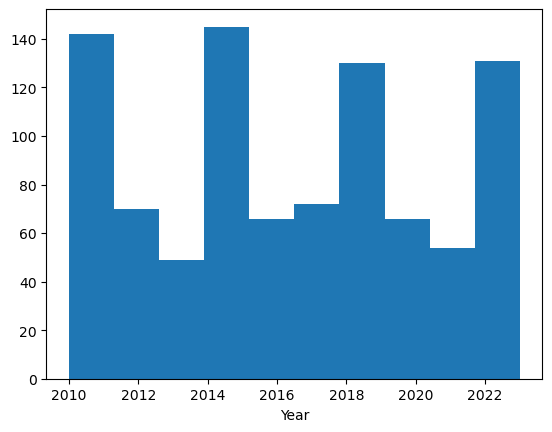

=====Mileage====
-0.027894275170231533


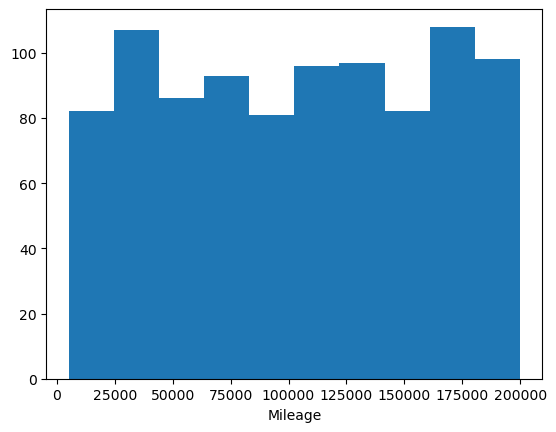

=====Engine_Size====
-0.008654731738121615


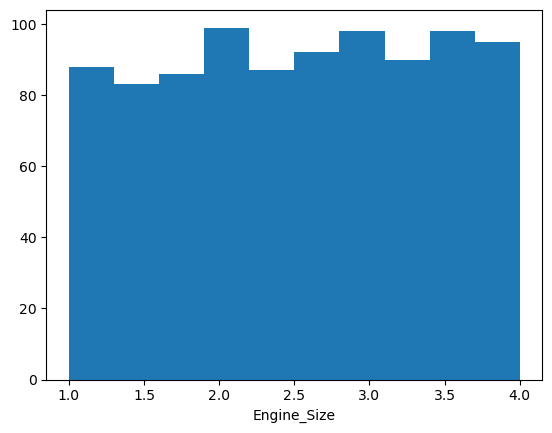

=====Previous_Owners====
-0.037643527507930846


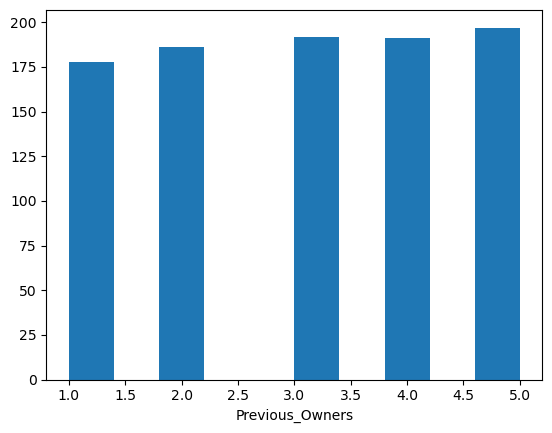

=====Price====
2.135546259049854


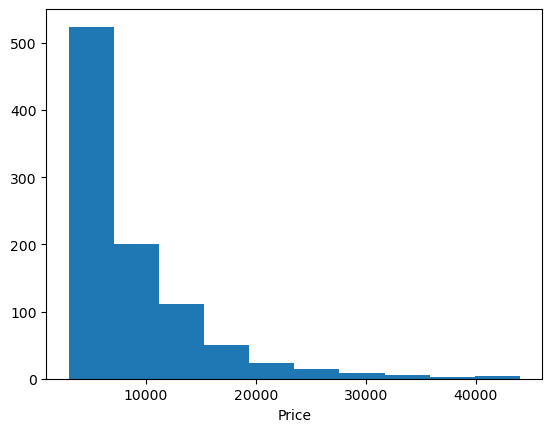

=====Car_Age====
-0.02439165025546357


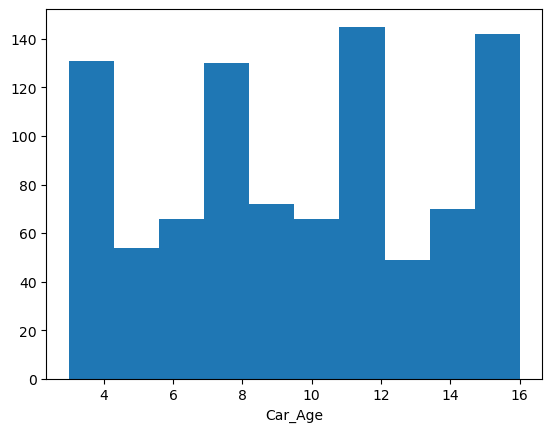

In [699]:
columns=df.select_dtypes(include='number')
for col in columns:
    
    print(f"====={col}====")
    print(df[col].skew())
    plt.xlabel(col)
    plt.hist(df[col])
    plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x19b47ae2e50>,
 'caps': [<matplotlib.lines.Line2D at 0x19b47a37950>,
 'boxes': [<matplotlib.lines.Line2D at 0x19b4797d990>],
 'medians': [<matplotlib.lines.Line2D at 0x19b47a35350>],
 'fliers': [<matplotlib.lines.Line2D at 0x19b47a35610>],
 'means': []}

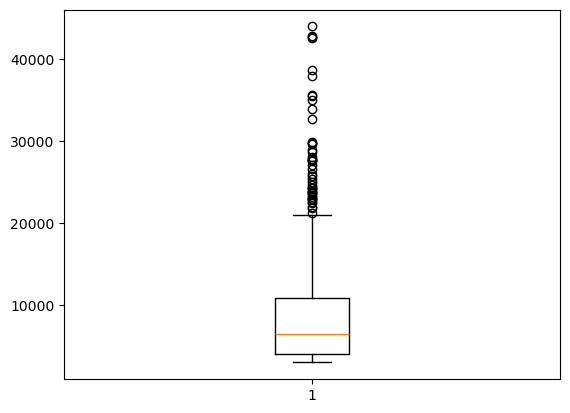

In [700]:
plt.boxplot(df["Price"])

In [701]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            923 non-null    object 
 1   Year             925 non-null    float64
 2   Mileage          930 non-null    float64
 3   Engine_Size      916 non-null    float64
 4   Fuel_Type        933 non-null    object 
 5   Transmission     923 non-null    object 
 6   Previous_Owners  944 non-null    int64  
 7   Price            944 non-null    float64
 8   Car_Age          925 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 66.5+ KB


In [702]:
#=============imputaion=============
SimpleImputer_o=[
    "Brand","Transmission","Fuel_Type"
]
SimpleImputer_mean=[
    "Year","Mileage","Engine_Size"
]

#===========encoding=========
OHE_cols=["Brand","Fuel_Type"]
ordianl_cols=["Transmission"]

#=====scaling =======
uniform_cols=["Mileage","Engine_Size","Car_Age"]
standard_cols=["Year"]


In [703]:
RC=RobustScaler()

y_train = RC.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_test = RC.transform(y_test.to_numpy().reshape(-1, 1))
import joblib

joblib.dump(RC, "target_scaler.pkl")

['target_scaler.pkl']

In [704]:
#================small pipline=========

simple_o_OHE=Pipeline([ #"Brand","Fuel_Type"
    ("imputer_o",SimpleImputer(strategy="most_frequent")),
    ("OHE",OneHotEncoder(sparse_output=False,handle_unknown="ignore"))
])

simple_o_ord=Pipeline([    #"Transmission"
    ("imputer_o",SimpleImputer(strategy="most_frequent")),
    ("ord",OrdinalEncoder())
])

simple_mean_uniforrm=Pipeline([ #"Mileage","Engine_Size","Year"
    ("imputer_mean",SimpleImputer(strategy="mean")),
    ("scaling",MinMaxScaler())
])




In [705]:
#=======transforms=============
transform=ColumnTransformer([
    
    ("simple_o_OHE",simple_o_OHE,["Brand","Fuel_Type"]),
    ("simple_o_ord",simple_o_ord,["Transmission"]),
    ("simple_mean_uniforrm",simple_mean_uniforrm,[ "Mileage","Engine_Size","Car_Age"]),
    ("previous_owners", "passthrough", ["Previous_Owners"])
    
    
])

In [706]:
X_train_transformed = transform.fit_transform(x_train)
X_test_transformed = transform.transform(x_test)

In [707]:
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    StackingRegressor
)
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
models = {
    "LinearRegression": LinearRegression(),
    "SGD": SGDRegressor(max_iter=1000, random_state=42),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "Bagging": BaggingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "Stacking": StackingRegressor(
        estimators=[
            ('lr', LinearRegression()),
            ('rf', RandomForestRegressor(random_state=42))
        ],
        final_estimator=Ridge()
    ),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

In [708]:
results = {}

for name, model in models.items():

    model.fit(X_train_transformed, y_train)

    y_pred = model.predict(X_test_transformed)
    #note
    y_pred_original = RC.inverse_transform(
    y_pred.reshape(-1, 1)
    ).ravel()

    results[name] = {
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

    print(name, "done")

LinearRegression done
SGD done
Lasso done
Ridge done
KNN done
SVM done
DecisionTree done
RandomForest done
ExtraTrees done
Bagging done
AdaBoost done
GradientBoosting done
HistGradientBoosting done
Stacking done
XGBoost done
CatBoost done
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 755, number of used features: 17
[LightGBM] [Info] Start training from score 0.295827
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [ ]:


results_df = pd.DataFrame(results).T

print(results_df.sort_values("R2", ascending=False))

                            R2       MAE      RMSE
CatBoost              0.777829  0.207947  0.467627
GradientBoosting      0.769595  0.233082  0.476213
HistGradientBoosting  0.762378  0.235251  0.483615
LightGBM              0.758713  0.237983  0.487330
Stacking              0.739726  0.274562  0.506141
XGBoost               0.703910  0.276470  0.539843
ExtraTrees            0.702843  0.264103  0.540815
RandomForest          0.698453  0.292166  0.544795
LinearRegression      0.693743  0.338465  0.549034
Ridge                 0.693263  0.337212  0.549464
Bagging               0.677081  0.305753  0.563771
SGD                   0.676163  0.338702  0.564572
SVM                   0.672391  0.288171  0.567851
AdaBoost              0.538205  0.478716  0.674187
DecisionTree          0.364172  0.418661  0.791090
KNN                   0.324033  0.507902  0.815678
Lasso                -0.002439  0.716038  0.993310


In [710]:
final_pipeline = Pipeline([
    ("preprocessing", transform),
    ("model", XGBRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [711]:
#عملناه علشان نتأكد إن أداء الموديل مش معتمد بس على تقسيمة واحدة.
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(
#     GradientBoostingRegressor(random_state=42),
#     X_train_transformed,
#     y_train.ravel(),
#     cv=5,
#     scoring="r2"
# )

# print(scores)
# print("Mean R2:", scores.mean())

In [712]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 150, 200, 250, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_transformed, y_train.ravel())



,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here...

In [713]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.7, 'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.03}
0.8581123251173297


In [714]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_transformed)

print("R2:", r2_score(y_test.ravel(), y_pred))

R2: 0.7943463887055845


In [715]:
final_model = Pipeline([
    ("preprocessing", transform),
    ("model", GradientBoostingRegressor(
        **random_search.best_params_,
        random_state=42
    ))
])

final_model.fit(x_train, y_train.ravel())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('simple_o_OHE', ...), ('simple_o_ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [716]:
import joblib

joblib.dump(final_model, "car_price_model.pkl")

['car_price_model.pkl']